In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes

In [3]:
data = load_diabetes()
X = data.data
y = data.target

print(data.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [10]:
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
print(model.predict(X[:5]))

[206.11667725  68.07103297 176.88279035 166.91445843 128.46225834]


In [13]:
y_pred = model.predict(X)



0.5177484222203499


In [21]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print(r2_score(y, y_pred))
mse = mean_squared_error(y, y_pred)
print(mse)
print(np.sqrt(mse))
print(mean_absolute_error(y, y_pred))
mape = np.mean(np.abs((y-y_pred) / y)) *100
print(mape)

0.5177484222203499
2859.69634758675
53.47612876402657
43.27745202531506
38.786179217948245


In [22]:
import statsmodels.api as sm

X_with_constant = sm.add_constant(X)
sm_model = sm.OLS(y, X_with_constant).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           3.83e-62
Time:                        16:09:53   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.576     59.061      0.0

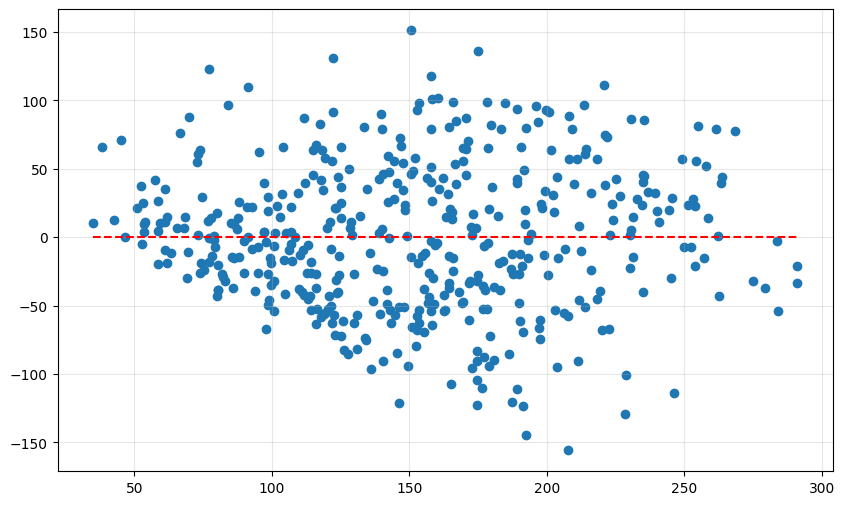

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, y-y_pred)
plt.hlines(y=0, xmin=min(y_pred), xmax=max(y_pred), colors='red', linestyles='dashed')
plt.grid(True, alpha=0.3)


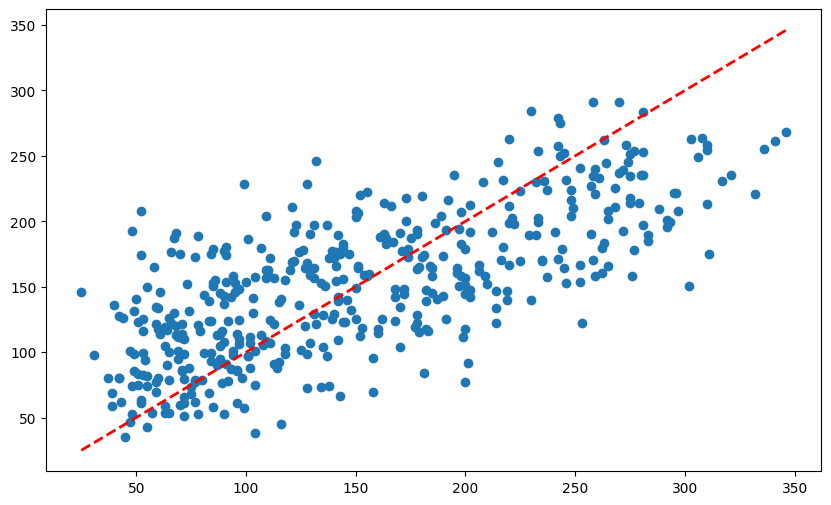

In [25]:
plt.figure(figsize=(10, 6))

plt.scatter(y, y_pred)

plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='dashed', linewidth=2)